# Research Visualizations

## Sustainable Practice Adoption Among Built Environment Professionals

This notebook generates publication-quality figures to communicate the study's findings.

The figures complement the statistical analyses presented in the analysis notebook and are intended for inclusion in the manuscript, GitHub repository, presentations, and portfolio.

Each visualization highlights a key aspect of the research findings, ranging from respondent characteristics to regression results and implementation priorities.

# Content

## 1. Import Libraries

## 2. Load Dataset

## 3. Figure 1 – Sample Characteristics

## 4. Figure 2 – Sustainability Awareness

## 5. Figure 3 – Sustainable Practice Adoption

## 6. Figure 4 – Adoption–Contribution Gap

## 7. Figure 5 – Correlation Matrix

## 8. Figure 6 – Regression Coefficients

## 9. Figure 7 – Conceptual Framework

## 10. Project Summary

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Publication style
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

In [69]:
df = pd.read_csv("CleanData_Final.csv")

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

df.head()

,AgeGroup,Gender,YearsExperience,Discipline,PolicyAwareness_NG,PolicyAwareness_NG_Code,PolicyAwareness_Global,PolicyAwareness_Global_Code,OrgAdoption,OrgAdoption_Code,...,ChangeScore,Perceived_Professional_Impact_on_SUD,Perceived_Professional_Impact_on_SUD_code,Key_Contribution_Areas,Contrib_Waste,Contrib_Water,Contrib_Energy,Contrib_GreenInfra,Contrib_ClimateDesign,ContributionScore
0,25 - 34,Male,6 - 10 years,Quantity Surveyors,Somewhat familiar,1.0,Somewhat familiar,1.0,"Yes, to some extent",1.0,...,3,To a great extent,2.0,Green Infrastructure,0,0,0,1,0,1
1,25 - 34,Male,3 - 5 years,Architect,Somewhat familiar,1.0,"Yes, i am very familiar",2.0,"Yes, to some extent",1.0,...,3,To a moderate extent,1.0,"Energy Efficiency, Green Infrastructure, Clima...",0,0,1,1,1,3
2,25 - 34,Male,3 - 5 years,Architect,Somewhat familiar,1.0,Somewhat familiar,1.0,Not really,0.0,...,1,To a great extent,2.0,"Waste Management, Energy Efficiency, Green Inf...",1,0,1,1,0,3
3,25 - 34,Female,3 - 5 years,Project Managers,Somewhat familiar,1.0,Somewhat familiar,1.0,"Yes, to some extent",1.0,...,1,To a great extent,2.0,"Water Conservation, Energy Efficiency, Climate...",0,1,1,0,1,3
4,25 - 34,Male,3 - 5 years,Architect,Somewhat familiar,1.0,Somewhat familiar,1.0,"Yes, to some extent",1.0,...,3,To a great extent,2.0,"Waste Management, Energy Efficiency, Climate-r...",1,0,1,0,1,3


In [70]:
import os

os.makedirs("figures", exist_ok=True)

In [71]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 300

## Figure 1. Distribution of Professional Disciplines

This figure illustrates the distribution of respondents across the different built environment professions represented in the study.

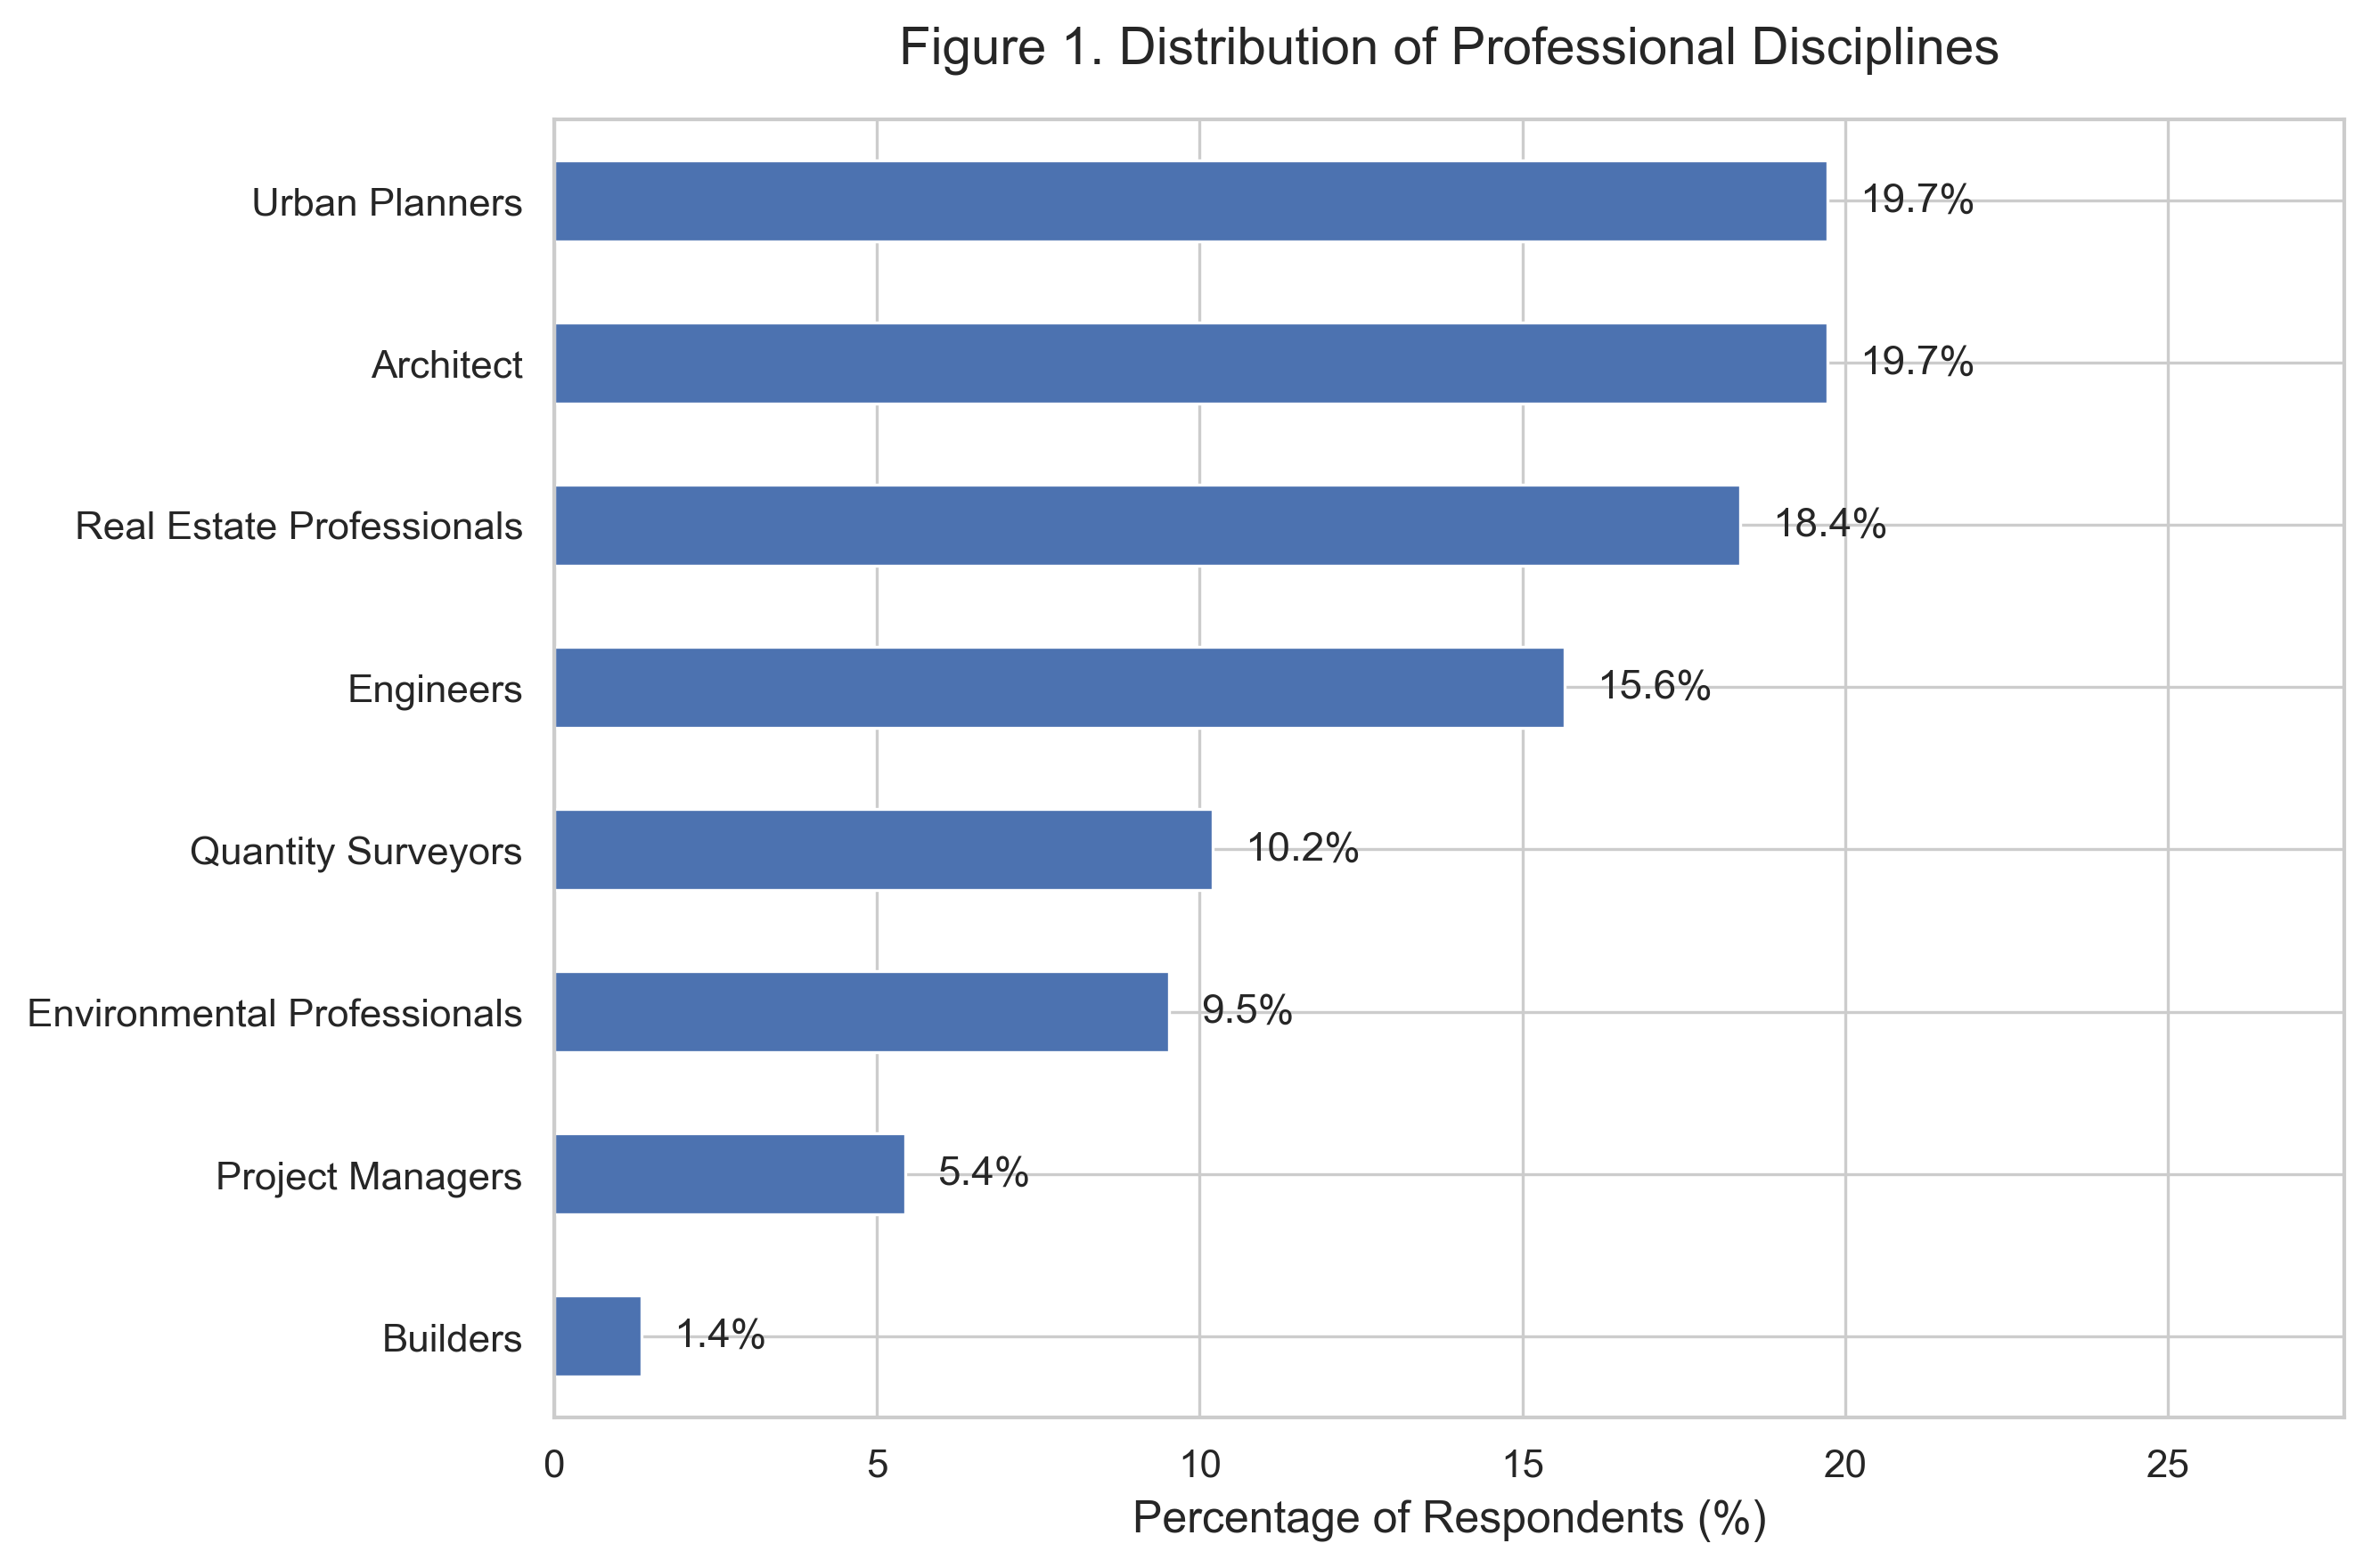

In [72]:
# Figure 1: Professional Discipline Distribution

discipline = (
    df["Discipline"]
    .value_counts(normalize=True)
    .sort_values() * 100
)

plt.figure(figsize=(9,6))

ax = discipline.plot(kind="barh")

plt.title("Figure 1. Distribution of Professional Disciplines", pad=15)
plt.xlabel("Percentage of Respondents (%)")
plt.ylabel("")

# Add percentage labels
for i, value in enumerate(discipline):
    ax.text(value + 0.5, i, f"{value:.1f}%", va="center")

plt.xlim(0, max(discipline)+8)

plt.tight_layout()

plt.savefig(
    "figures/Figure1_Discipline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 2. Sustainability Policy Awareness

This figure presents respondents' level of familiarity with national sustainability policies.

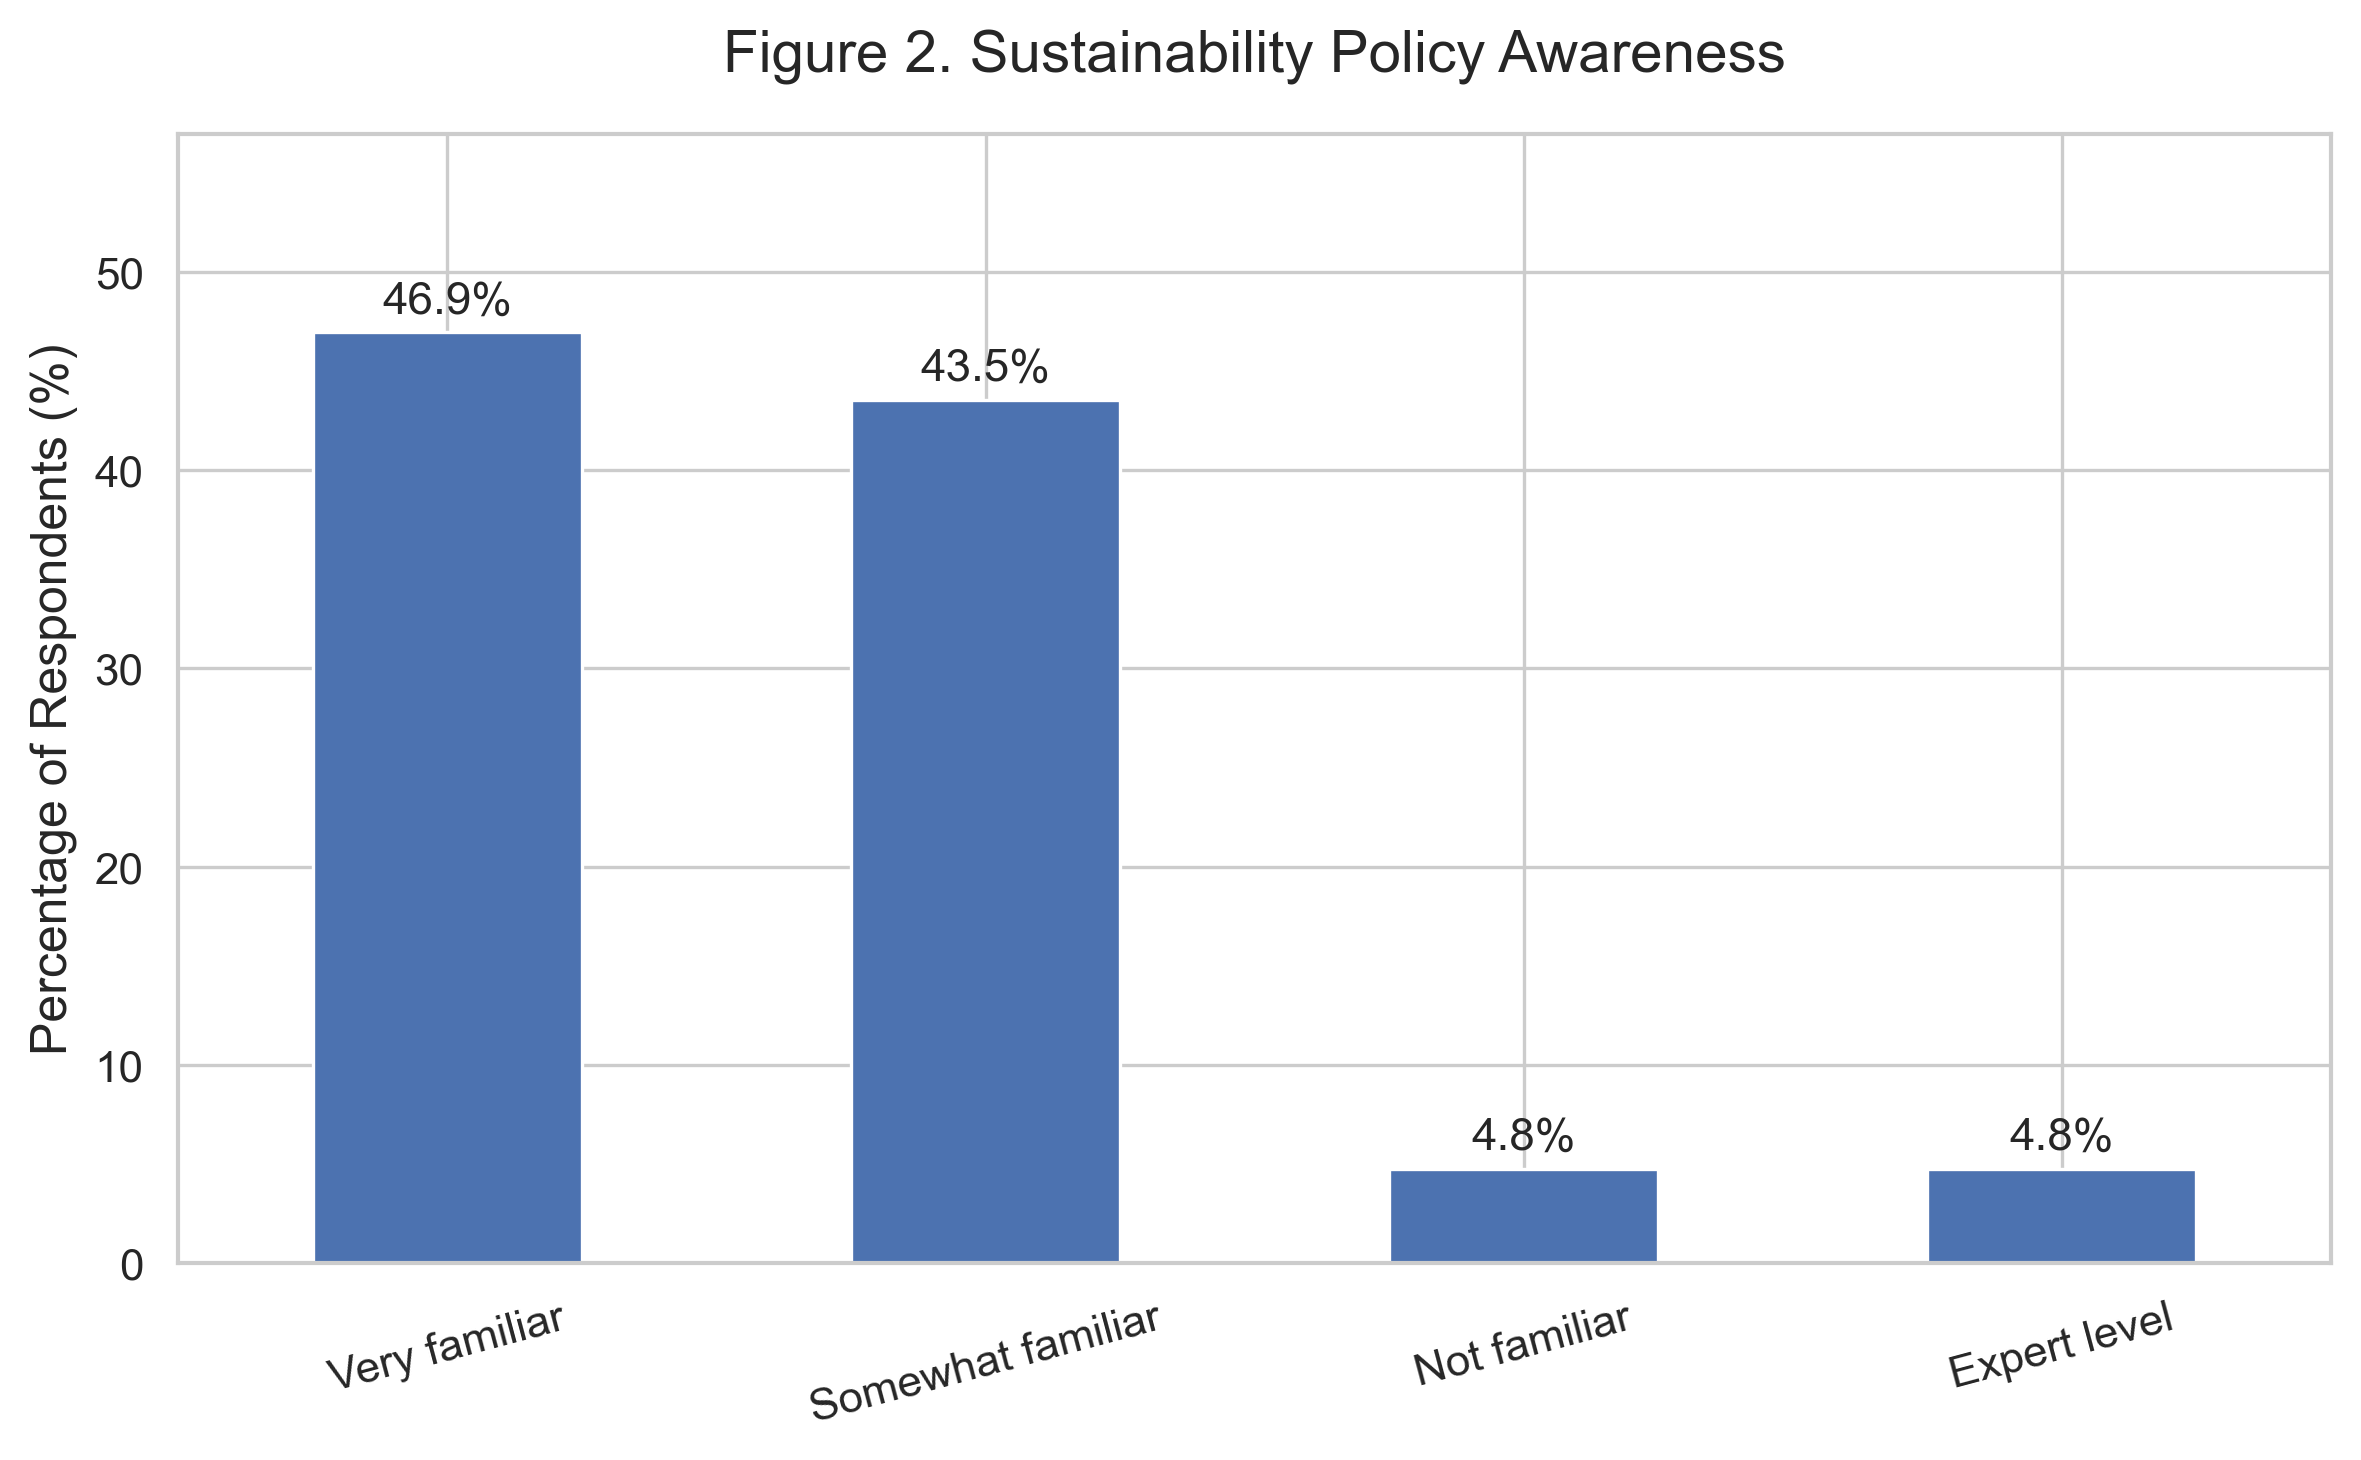

In [73]:
awareness = (
    df["PolicyAwareness_NG"]
    .value_counts(normalize=True)
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

ax = awareness.plot(kind="bar")

plt.title("Figure 2. Sustainability Policy Awareness", pad=15)
plt.xlabel("")
plt.ylabel("Percentage of Respondents (%)")

plt.xticks(rotation=15)

# Add value labels
for i, value in enumerate(awareness):
    ax.text(i, value + 1,
            f"{value:.1f}%",
            ha="center")

plt.ylim(0, max(awareness)+10)

plt.tight_layout()

plt.savefig(
    "figures/Figure2_PolicyAwareness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 3. Current Sustainable Practices

This figure illustrates the proportion of professionals currently implementing different sustainable practices.

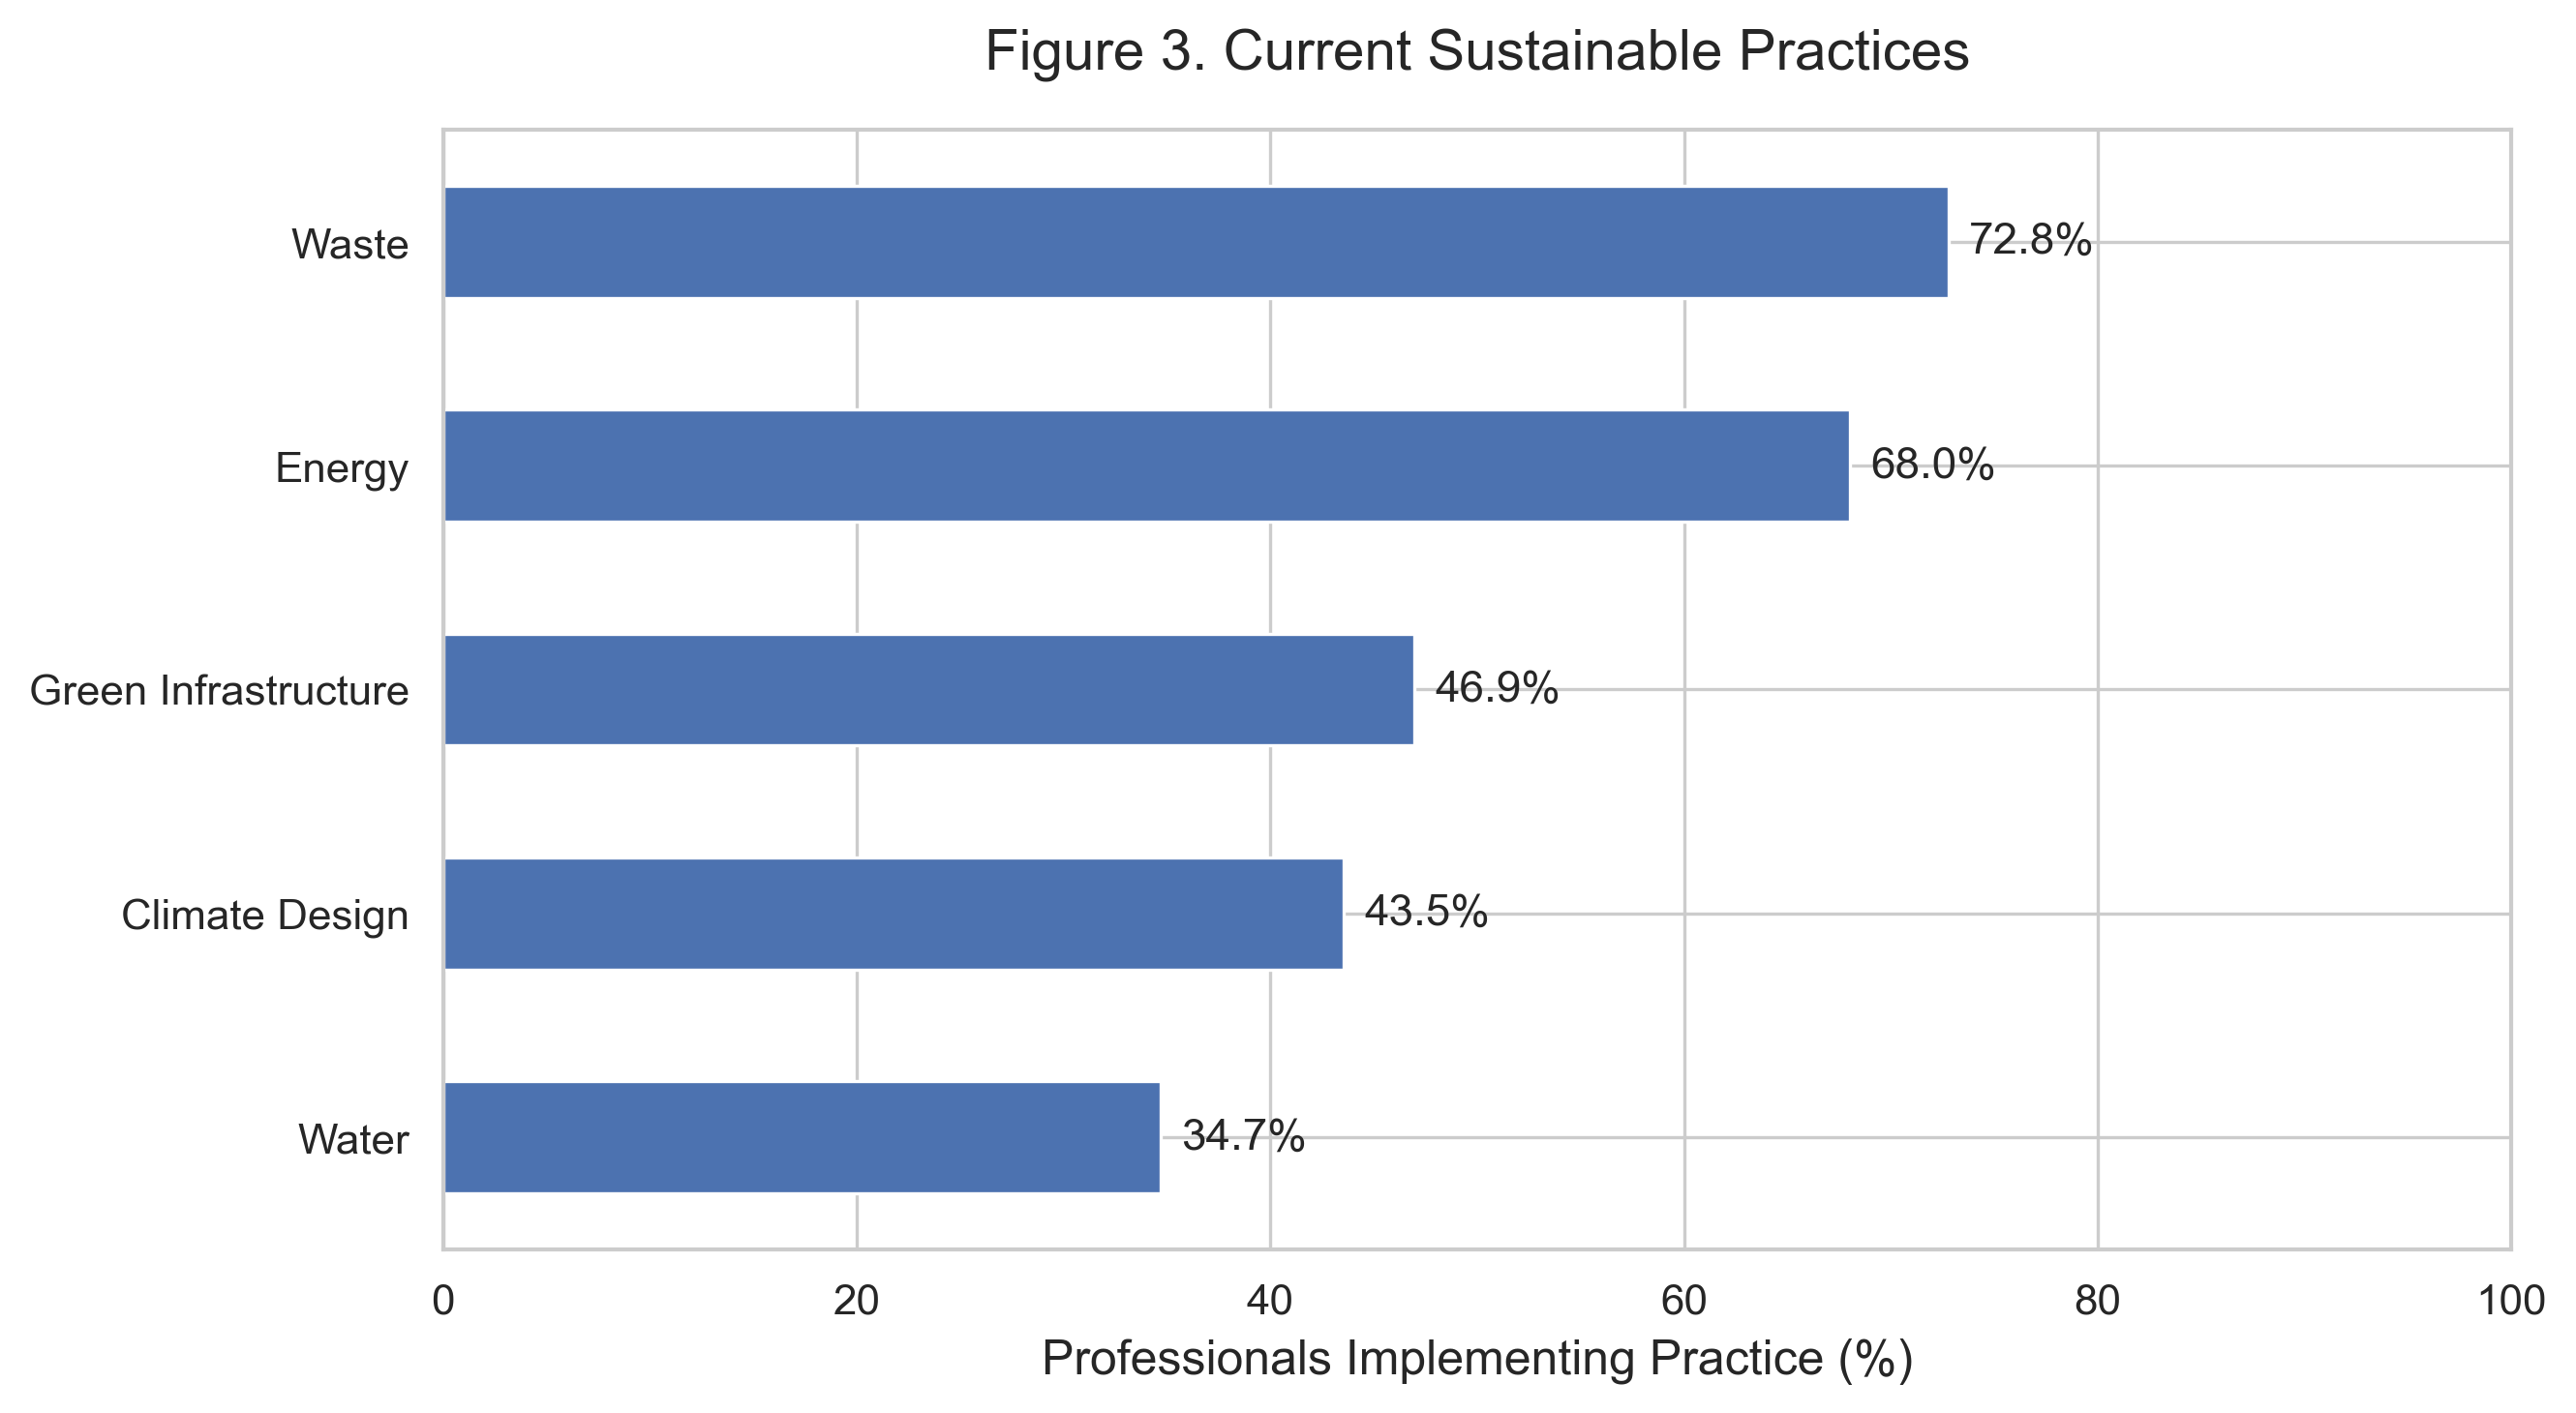

In [74]:
practice = (
    df[
        [
            "Adopt_Waste",
            "Adopt_Water",
            "Adopt_Energy",
            "Adopt_GreenInfra",
            "Adopt_ClimateDesign"
        ]
    ].mean() * 100
)

practice.index = [
    "Waste",
    "Water",
    "Energy",
    "Green Infrastructure",
    "Climate Design"
]

practice = practice.sort_values()

plt.figure(figsize=(9,5))

ax = practice.plot(kind="barh")

plt.title("Figure 3. Current Sustainable Practices", pad=15)
plt.xlabel("Professionals Implementing Practice (%)")
plt.ylabel("")

for i, value in enumerate(practice):
    ax.text(value + 1,
            i,
            f"{value:.1f}%",
            va="center")

plt.xlim(0,100)

plt.tight_layout()

plt.savefig(
    "figures/Figure3_CurrentPractice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 4. Current Practice versus Perceived Areas of Contribution

This figure compares the proportion of professionals currently implementing sustainable practices with the proportion who believe they can make meaningful contributions in each sustainability domain.

The difference between both measures represents the Practice–Contribution Gap and identifies priority areas for capacity building and policy intervention.

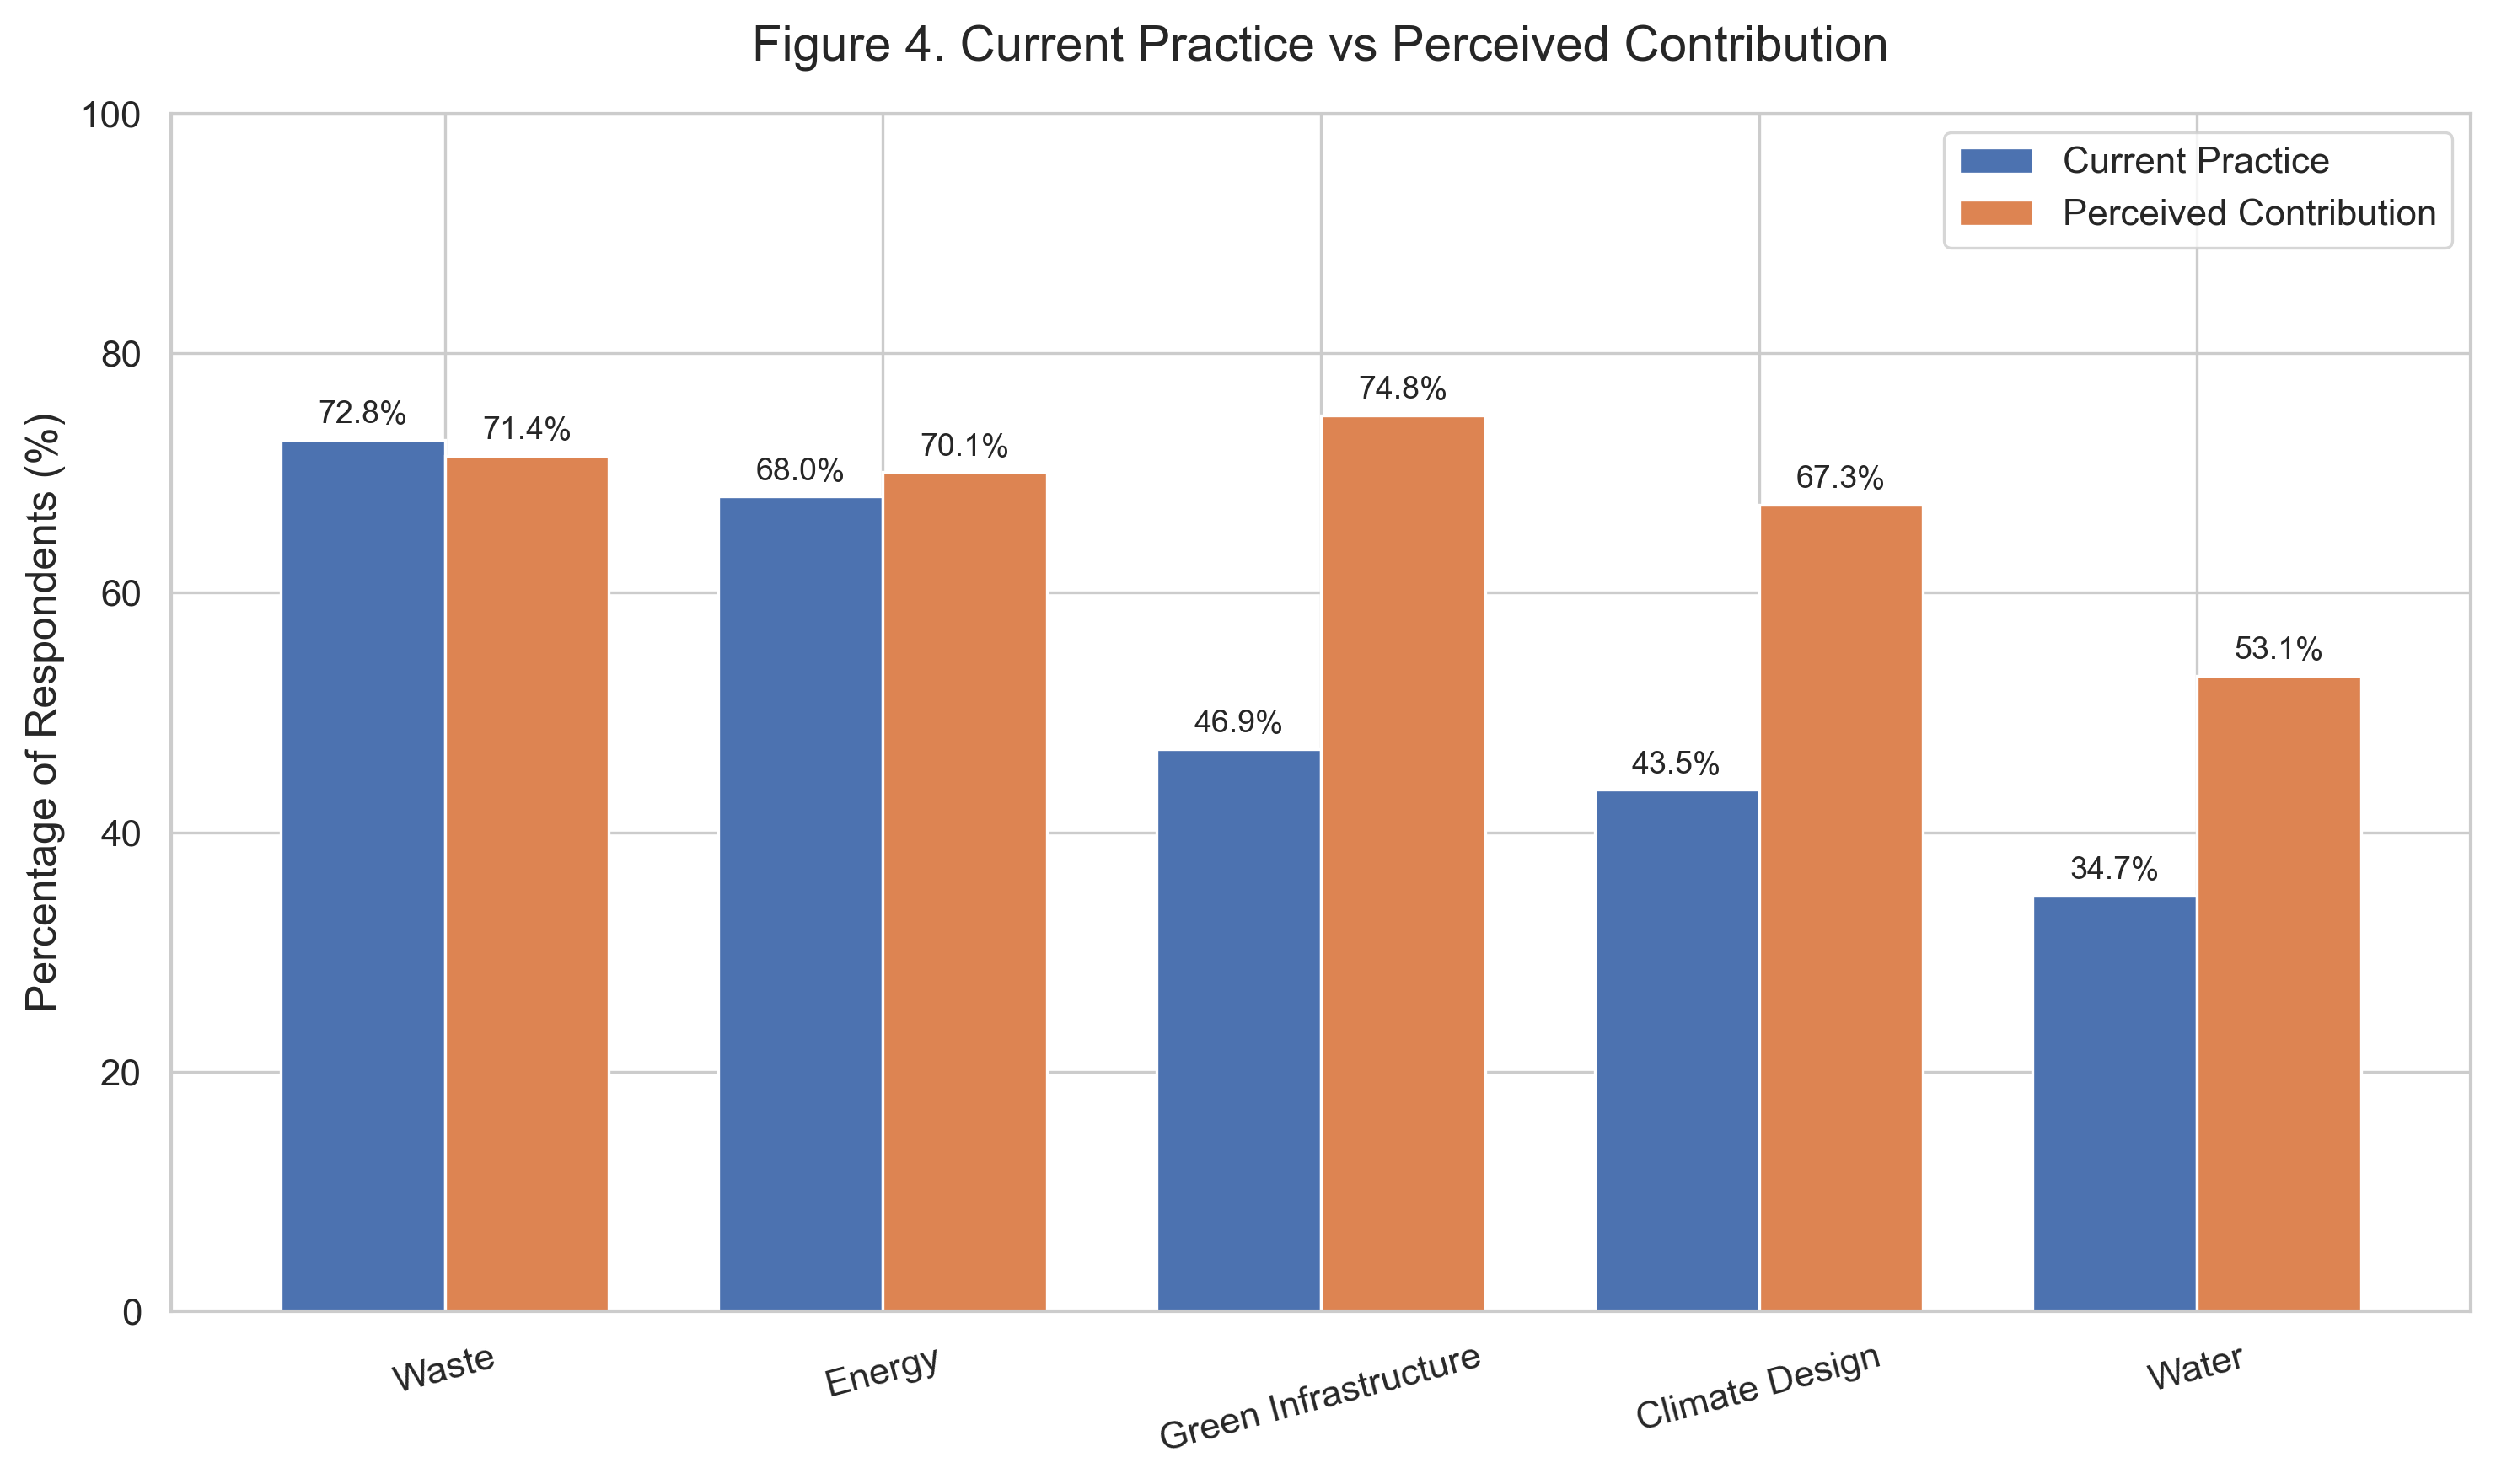

In [75]:
practice = (
    df[
        [
            "Adopt_Waste",
            "Adopt_Water",
            "Adopt_Energy",
            "Adopt_GreenInfra",
            "Adopt_ClimateDesign"
        ]
    ].mean()*100
)

contribution = (
    df[
        [
            "Contrib_Waste",
            "Contrib_Water",
            "Contrib_Energy",
            "Contrib_GreenInfra",
            "Contrib_ClimateDesign"
        ]
    ].mean()*100
)

practice.index = [
    "Waste",
    "Water",
    "Energy",
    "Green Infrastructure",
    "Climate Design"
]

contribution.index = practice.index

comparison = pd.DataFrame({
    "Current Practice": practice,
    "Perceived Contribution": contribution
})

comparison = comparison.loc[
    [
        "Waste",
        "Energy",
        "Green Infrastructure",
        "Climate Design",
        "Water"
    ]
]

ax = comparison.plot(
    kind="bar",
    figsize=(10,6),
    width=0.75
)

plt.title(
    "Figure 4. Current Practice vs Perceived Contribution",
    pad=15
)

plt.ylabel("Percentage of Respondents (%)")
plt.xlabel("")

plt.xticks(rotation=15)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9,
        padding=3
    )

plt.ylim(0,100)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/Figure4_PracticeContributionGap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Figure 4 compares the proportion of professionals currently implementing key sustainable practices with the proportion who believe they can make meaningful contributions within those same domains. The differences between these measures reveal a clear **adoption–contribution gap**, providing insight into where the greatest unrealised implementation potential exists.

Waste Management and Energy Efficiency exhibit relatively high implementation rates and comparatively small gaps between current practice and perceived contribution. These findings suggest that such practices have become more integrated into routine professional activities and are often achievable through project-level decisions, organisational policies, operational efficiencies, and existing market incentives. As a result, professionals appear better positioned to implement these interventions within the current institutional environment.

In contrast, Green Infrastructure, Climate-responsive Design, and Water Conservation demonstrate substantially larger implementation gaps. Although respondents recognise these domains as areas where they can make significant contributions, current implementation remains comparatively limited. Unlike waste management and energy efficiency, these interventions frequently depend on enabling conditions that extend beyond the influence of individual professionals, including supportive planning regulations, resilient public infrastructure, coordinated governance, financing mechanisms, procurement systems, and client demand.

These findings complement the regression analysis, which consistently identified **Infrastructure** as the strongest predictor of sustainable practice adoption. Taken together, the results suggest that professionals generally possess both the awareness and willingness to contribute to sustainable urban development. However, their ability to translate this knowledge into practice appears to be constrained primarily by systemic implementation barriers rather than deficiencies in professional awareness.

This interpretation is also consistent with Nigeria's broader urban development and climate finance landscape. National assessments indicate that although important progress has been made in areas such as renewable energy and climate-smart agriculture, significant investment gaps remain in climate-resilient urban infrastructure, sustainable buildings, integrated water systems, and nature-based urban solutions. Similarly, broader assessments of Nigeria's urban development highlight persistent challenges related to infrastructure deficits, institutional capacity, planning systems, and financing, all of which influence the implementation of sustainable urban development initiatives. These broader structural conditions provide important context for understanding why professionals perceive the greatest unrealised implementation potential in Green Infrastructure, Climate-responsive Design, and Water Conservation.

Beyond describing current practice, Figure 4 offers one of the study's principal contributions. The adoption–contribution gap functions as an evidence-based implementation diagnostic, identifying sustainability domains where future investments in professional capacity building, institutional strengthening, planning reform, financing mechanisms, and resilient urban infrastructure are likely to generate the greatest implementation gains. Rather than suggesting that professionals require greater awareness, the findings indicate that achieving meaningful progress in sustainable urban development will depend on strengthening the enabling systems that allow existing professional knowledge and willingness to be translated into practice.

## Figure 5. Correlation Matrix

This figure illustrates the relationships among the principal variables included in the regression analysis.

The heatmap provides a visual summary of the strength and direction of pairwise correlations prior to regression modelling.

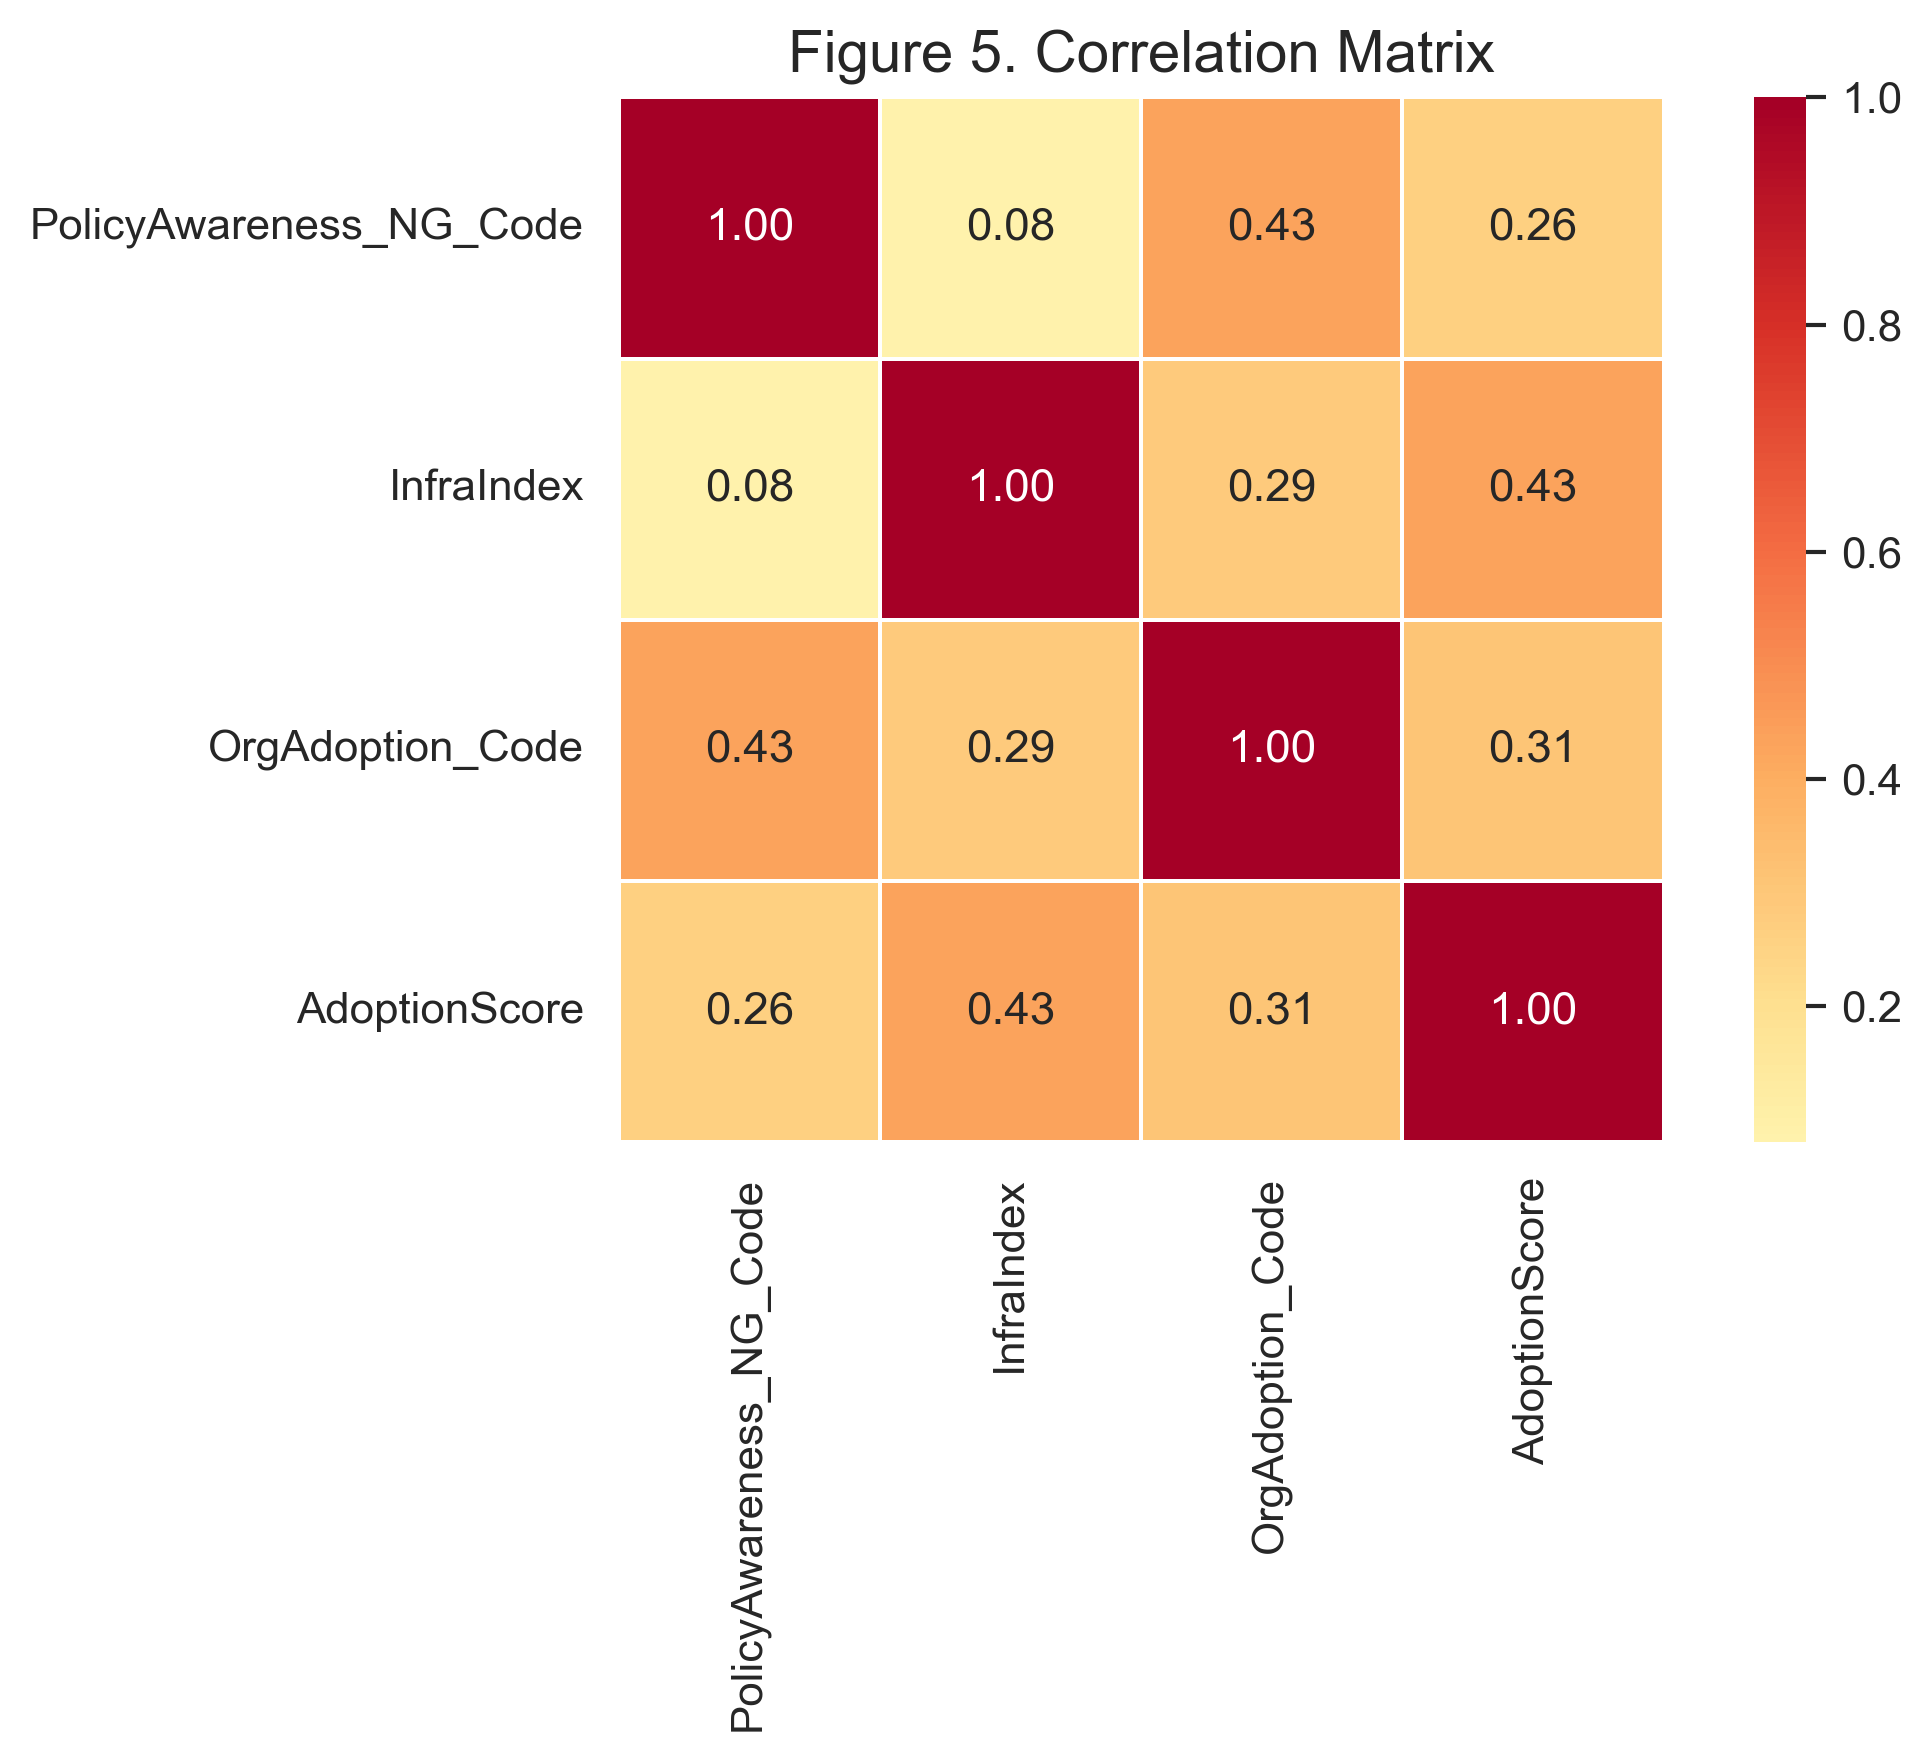

In [76]:
corr = df[
    [
        "PolicyAwareness_NG_Code",
        "InfraIndex",
        "OrgAdoption_Code",
        "AdoptionScore"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    center=0,
    square=True,
    linewidths=.5,
    fmt=".2f"
)

plt.title("Figure 5. Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "figures/Figure5_CorrelationHeatmap.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation matrix provides an initial overview of the relationships among the principal variables examined in the study prior to multivariate analysis.

Infrastructure demonstrates the strongest positive association with Sustainable Practice Adoption, indicating that professionals operating within environments with greater infrastructural support are more likely to implement sustainable practices. This preliminary finding is consistent with the subsequent regression analyses, where Infrastructure remained the strongest and most consistent predictor of sustainable practice adoption.

Policy Awareness and Organisational Adoption exhibit positive but comparatively weaker relationships with Sustainable Practice Adoption. These results suggest that while awareness and organisational commitment are important enabling factors, they alone do not fully explain implementation. Their relatively modest correlations reinforce the argument that knowledge of sustainability principles must be complemented by supportive institutional and physical environments before widespread implementation can occur.

Overall, the correlation analysis provides early evidence that sustainable practice adoption is influenced by a combination of individual awareness, organisational context, and enabling infrastructure. The stronger association observed for Infrastructure foreshadows the central finding of the study: that implementation is shaped less by awareness deficits and more by the availability of the institutional and infrastructural conditions necessary to translate professional knowledge into practice.

These findings support the broader argument advanced throughout the manuscript that Nigeria's sustainable urban development challenge is increasingly one of implementation readiness rather than awareness alone. While professionals generally recognise the importance of sustainable urban development, successful implementation appears to depend on the broader systems within which they operate, including infrastructure, institutional capacity, governance arrangements, and implementation support.

## Figure 6. Relative Influence of Predictors on Sustainable Practice Adoption

This figure presents the standardized regression coefficients (Beta values) from the final multiple linear regression model (Model 2).

Standardized coefficients enable direct comparison of the relative influence of each predictor on Sustainable Practice Adoption after controlling for the remaining variables.

Solid bars represent predictors included in the final model. Infrastructure remained the only statistically significant predictor, highlighting its dominant influence on sustainable practice adoption.

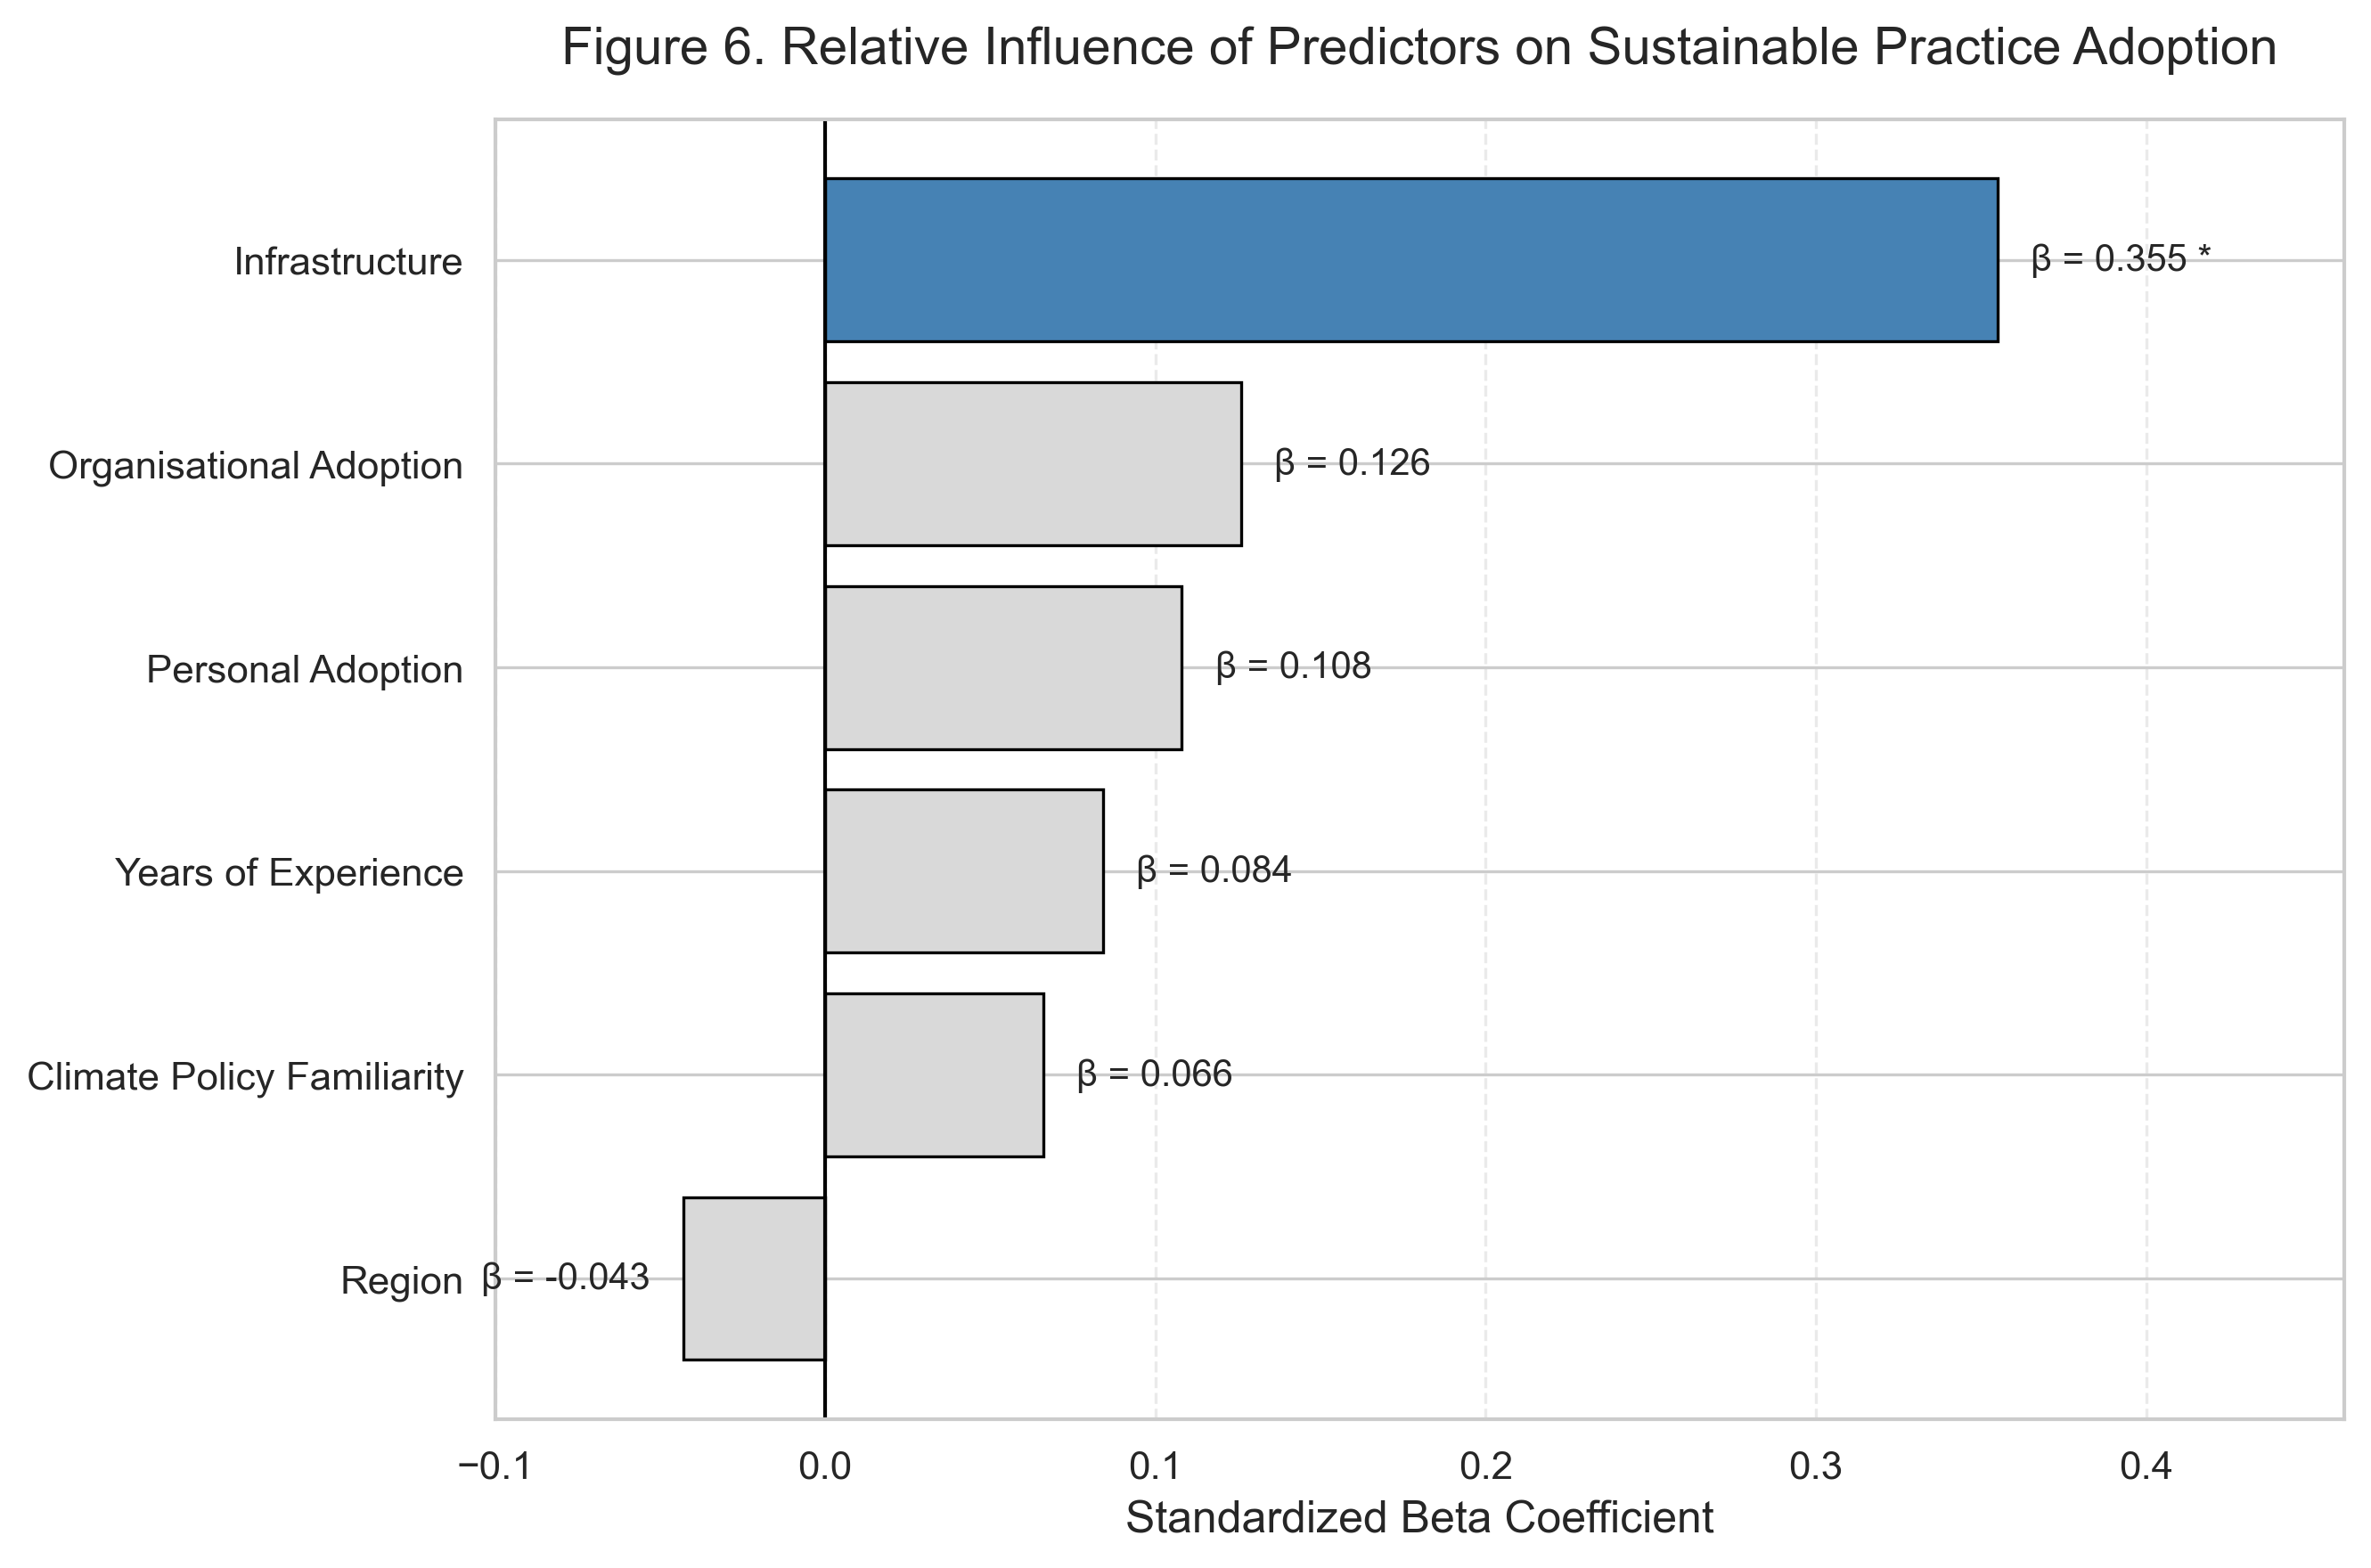

In [77]:
# Final SPSS Model 2
coef = pd.DataFrame({
    "Predictor": [
        "Infrastructure",
        "Organisational Adoption",
        "Personal Adoption",
        "Years of Experience",
        "Climate Policy Familiarity",
        "Region"
    ],
    "Beta": [
        0.355,
        0.126,
        0.108,
        0.084,
        0.066,
        -0.043
    ],
    "p_value": [
        0.000,
        0.144,
        0.204,
        0.275,
        0.443,
        0.557
    ]
})

# Keep Infrastructure at the top
coef = coef.sort_values("Beta", ascending=True)

# Create Figure

plt.figure(figsize=(9,6))

# Colour bars
colors = [
    "steelblue" if p < 0.05 else "#D9D9D9"
    for p in coef["p_value"]
]

bars = plt.barh(
    coef["Predictor"],
    coef["Beta"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Zero reference line
plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

# Gridlines
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Labels

plt.title(
    "Figure 6. Relative Influence of Predictors on Sustainable Practice Adoption",
    fontsize=14,
    pad=15
)

plt.xlabel(
    "Standardized Beta Coefficient",
    fontsize=12
)

plt.ylabel("")

# Annotate Beta values
for i, (_, row) in enumerate(coef.iterrows()):

    label = f"β = {row['Beta']:.3f}"

    if row["p_value"] < 0.05:
        label += " *"

    if row["Beta"] >= 0:
        x = row["Beta"] + 0.01
        ha = "left"
    else:
        x = row["Beta"] - 0.01
        ha = "right"

    plt.text(
        x,
        i,
        label,
        ha=ha,
        va="center",
        fontsize=10
    )

# Axis limits

plt.xlim(-0.10, 0.46)

plt.tight_layout()

# Save
plt.savefig(
    "figures/Figure6_RegressionCoefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### ***Note.** Standardized beta coefficients are reported from the final multiple linear regression model (Model 2). Infrastructure remained the only statistically significant predictor of Sustainable Practice Adoption (β = 0.355, *p* < .001). The asterisk (*) indicates statistical significance at the 0.05 level.*

### Interpretation

Figure 6 presents the standardized regression coefficients from the final multiple linear regression model, enabling direct comparison of the relative influence of each predictor after controlling for all other variables.

Infrastructure emerged as the only statistically significant predictor of Sustainable Practice Adoption (β = 0.355, *p* < .001), exerting a substantially greater influence than every other variable included in the model. This finding indicates that professionals operating within environments supported by adequate infrastructure are considerably more likely to implement sustainable practices than those operating under less supportive conditions.

Although Organisational Adoption, Personal Adoption, Climate Policy Familiarity, and Years of Experience all exhibited positive regression coefficients, none remained statistically significant after adjustment for the other predictors. This suggests that while these factors contribute to sustainable practice adoption, their independent influence is comparatively limited once enabling infrastructure is taken into account.

Interestingly, Climate Policy Familiarity demonstrated a stronger relationship with Sustainable Practice Adoption in the initial regression model but became markedly weaker after Organisational Adoption and Personal Adoption were introduced. This pattern suggests that part of the apparent influence of policy familiarity may operate indirectly through organisational environments that encourage sustainability practices rather than through awareness alone.

Overall, the regression findings provide robust empirical support for one of the study's central conclusions: sustainable practice adoption among built environment professionals is shaped primarily by enabling infrastructure rather than awareness alone. The results reinforce the argument that Nigeria's sustainable urban development challenge is increasingly characterised by an implementation readiness gap, where professionals possess the knowledge and willingness to contribute but remain constrained by the infrastructural, institutional, and governance conditions necessary for implementation.

## Figure 7. Conceptual Framework of Sustainable Practice Adoption

This figure presents a conceptual framework synthesising the empirical findings of the study.

Unlike the previous figures, this framework is not generated directly from the dataset. Instead, it integrates descriptive statistics, regression analysis, and policy implications into a unified explanation of the adoption of sustainable practices among built environment professionals.

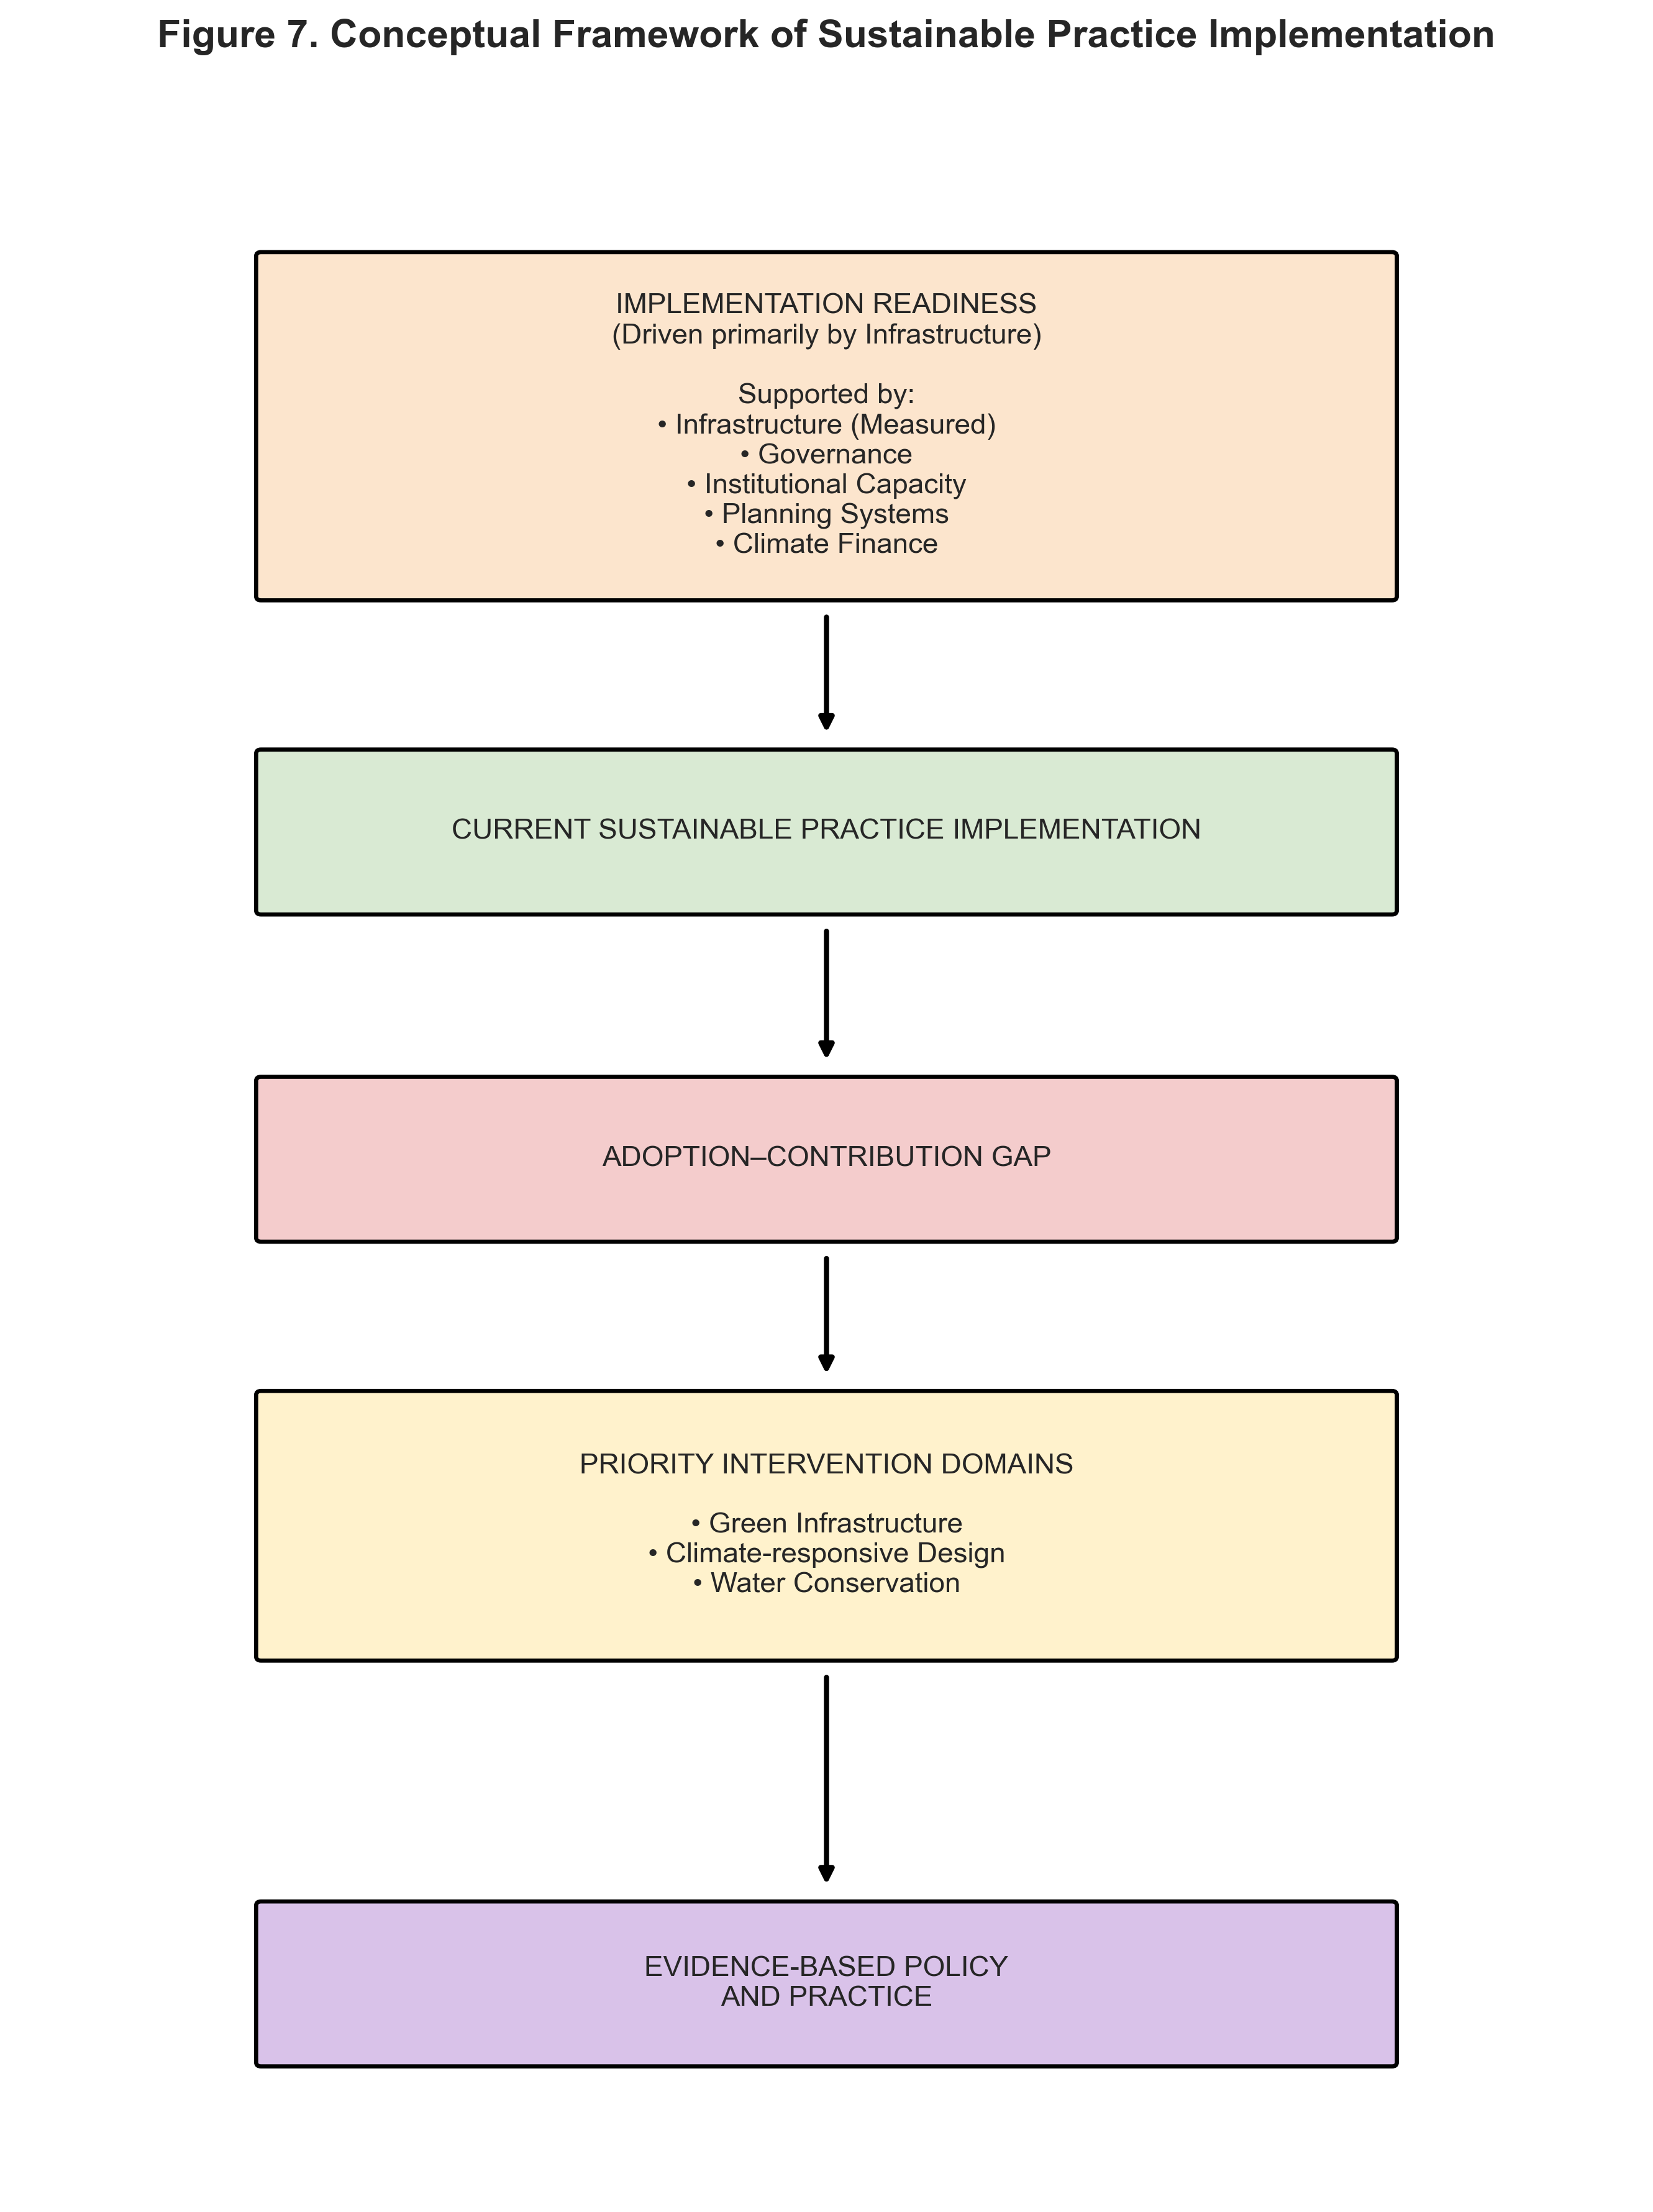

In [78]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 12))

ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis("off")

# Helper function

def draw_box(x, y, width, height, text, color):

    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.6,
        edgecolor="black",
        facecolor=color
    )

    ax.add_patch(patch)

    ax.text(
        x + width/2,
        y + height/2,
        text,
        ha="center",
        va="center",
        fontsize=11
    )

    return patch


def connect(box1, box2):

    x = box1.get_x() + box1.get_width()/2

    ax.annotate(
        "",
        xy=(
            box2.get_x() + box2.get_width()/2,
            box2.get_y() + box2.get_height()
        ),
        xytext=(
            x,
            box1.get_y()
        ),
        arrowprops=dict(
            arrowstyle="-|>",
            lw=2,
            color="black",
            shrinkA=8,
            shrinkB=8
        )
    )

# Draw Framework

top = draw_box(
    1.5,
    12.2,
    7,
    2.6,

    "IMPLEMENTATION READINESS\n"
    "(Driven primarily by Infrastructure)\n\n"

    "Supported by:\n"

    "• Infrastructure (Measured)\n"
    "• Governance\n"
    "• Institutional Capacity\n"
    "• Planning Systems\n"
    "• Climate Finance",

    "#FCE5CD"
)


practice = draw_box(
    1.5,
    9.8,
    7,
    1.2,

    "CURRENT SUSTAINABLE PRACTICE IMPLEMENTATION",

    "#D9EAD3"
)


gap = draw_box(
    1.5,
    7.3,
    7,
    1.2,

    "ADOPTION–CONTRIBUTION GAP",

    "#F4CCCC"
)


priority = draw_box(
    1.5,
    4.1,
    7,
    2,

    "PRIORITY INTERVENTION DOMAINS\n\n"

    "• Green Infrastructure\n"
    "• Climate-responsive Design\n"
    "• Water Conservation",

    "#FFF2CC"
)


policy = draw_box(
    1.5,
    1.0,
    7,
    1.2,

    "EVIDENCE-BASED POLICY\nAND PRACTICE",

    "#D9C2E9"
)

# Connect Framework

connect(top, practice)
connect(practice, gap)
connect(gap, priority)
connect(priority, policy)

# Title

plt.title(
    "Figure 7. Conceptual Framework of Sustainable Practice Implementation",
    fontsize=15,
    weight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "figures/Figure7_Conceptual_Framework.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


*The conceptual framework presented in Figure 7 is an evidence-based synthesis of the empirical findings and supporting literature. Unlike the statistical figures, it represents the study's conceptual interpretation rather than a direct output of the dataset.*

# Project Summary

This notebook presents the publication-ready visualizations developed to support the accompanying study on sustainable practice adoption among built environment professionals in Nigeria.

The figures demonstrate five principal findings:

- Built environment professionals exhibit relatively high sustainability awareness.
- Sustainable practice adoption remains moderate across the profession.
- Infrastructure consistently emerged as the strongest predictor of sustainable practice implementation.
- Professionals perceive substantially greater opportunities to contribute than are reflected in current practice, giving rise to the Adoption–Contribution Gap.
- The largest unrealized implementation potential exists in Green Infrastructure, Climate-responsive Design, and Water Conservation.

Together, these visualizations support the study's central argument that the primary challenge is enabling implementation rather than increasing awareness. The Adoption–Contribution Gap provides an evidence-based framework for prioritizing sustainability interventions within urban governance.
